In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed


/home/anagha/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def hill(X, X0, lambda_, n):
    H1 = (X ** n) / (X0 ** n + X ** n)
    H2 = (X0 ** n) / (X0 ** n + X ** n)
    return H2 + lambda_ * H1

def interactions(t, x, gamma_A, gamma_B, g_A, g_B, A0B, B0A, A0A, B0B, nAtoB, nBtoA, nAtoA, nBtoB, lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB):
    dxdt = np.zeros(2)
    dxdt[0] = g_A * hill(x[1], B0A, lambda_BtoA, nBtoA) - gamma_A * x[0]
    dxdt[1] = g_B * hill(x[0], A0B, lambda_AtoB, nAtoB) - gamma_B * x[1]
    return dxdt

In [3]:
domain = (0,500)
gamma_A = 1.5  #0.3 for monostable with A high and 0.5 for bistable. 1.2 for monostability when we have   B high
gamma_B = 0.5
g_A = 10
g_B = 5
A0B = 2
B0A = 2
A0A = 80
B0B = 80
nAtoB = 5
nBtoA = 5
nAtoA = 4
nBtoB = 4
lambda_AtoB = 0.1
lambda_BtoA = 0.1
lambda_AtoA = 5
lambda_BtoB = 5



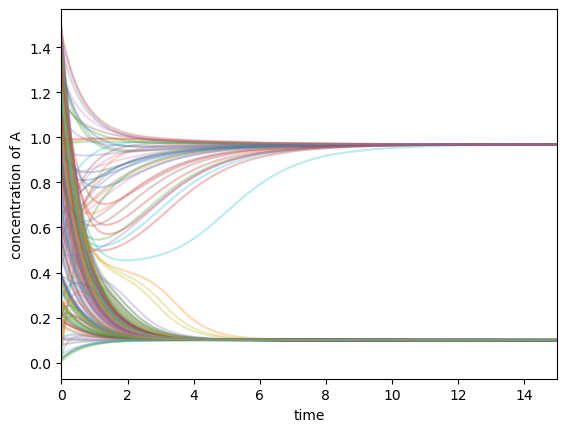

In [11]:
final_A_values = []


fig, ax = plt.subplots()


for _ in range(200):

    A = 10 * np.random.rand()
    B = 10 * np.random.rand()

    # Solve steady state solution for A and B
    t_eval = np.linspace(domain[0], domain[1], 5000)  # Increase the time resolution
    sol = solve_ivp(interactions, domain, [A, B], args=(gamma_A, gamma_B, g_A, g_B, A0B, B0A, A0A, B0B, nAtoB, nBtoA, nAtoA, nBtoB, lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB), method='RK45', t_eval=t_eval)


    ax.plot(sol.t, sol.y[0]/(g_A/gamma_A), alpha=0.3)
    #ax.plot(sol.t, sol.y[1],alpha=0.3,  color='red',label='Gene B' if _ == 0 else "")

    # append final conc. of A from each run
    final_A_values.append(sol.y[0][-1]/(g_A/gamma_A))
    
ax.set_ylabel("concentration of A")
ax.set_xlabel("time")
ax.set_xlim(0, 15)  

plt.show()    

In [6]:
ax.set_xlim(0, 20)  

plt.show() 

/home/anagha/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/anagha/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/anagha/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/anagha/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy vers

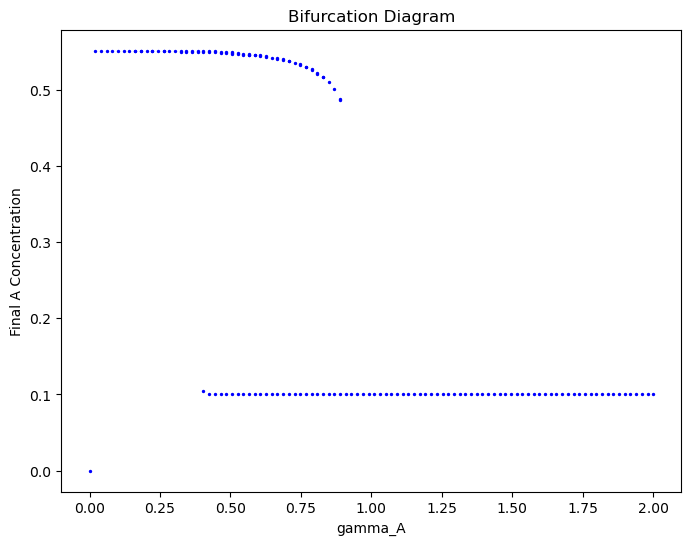

In [11]:

def get_final_A(gamma_A):
    final_A_values = []
    domain = (0, 500)
    gamma_B = 0.5
    g_A, g_B = 10, 10
    A0B, B0A, A0A, B0B = 2, 2, 10, 10
    nAtoB, nBtoA, nAtoA, nBtoB = 5, 5, 3, 3
    lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB = 0.1, 0.1, 3, 3

    for _ in range(50):  # Reduced to 50 ICs for speed
        A, B = 10 * np.random.rand(), 10 * np.random.rand()
        sol = solve_ivp(interactions, domain, [A, B], args=(gamma_A, gamma_B, g_A, g_B, A0B, B0A, A0A, B0B, nAtoB, nBtoA, nAtoA, nBtoB, lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB), method='RK45')
        final_A_values.append(sol.y[0][-1] / (g_A / gamma_A))

    return gamma_A, np.unique(np.round(final_A_values, 3))  # Rounding for uniqueness

gamma_A_values = np.linspace(0, 2, 100)  # 100 steps for speed
results = Parallel(n_jobs=-1)(delayed(get_final_A)(gamma_A) for gamma_A in gamma_A_values)

# Plot
plt.figure(figsize=(8, 6))
for gamma_A, final_A_set in results:
    plt.scatter([gamma_A] * len(final_A_set), final_A_set, color="blue", s=2)
plt.xlabel("gamma_A")
plt.ylabel("Final A Concentration")
plt.title("Bifurcation Diagram")
plt.show()


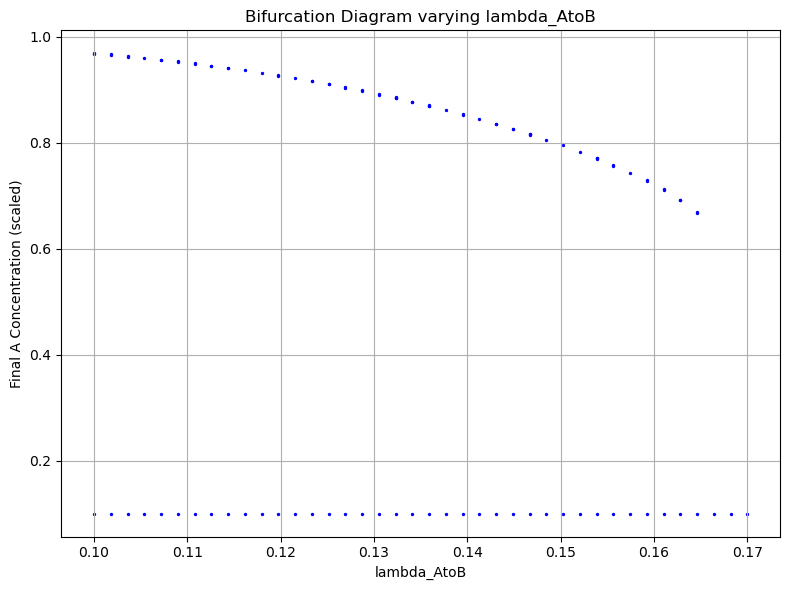

In [13]:
gamma_A = 1.5
gamma_B = 0.5
g_A, g_B = 10, 5
A0B, B0A, A0A, B0B = 2, 2, 80, 80
nAtoB, nBtoA, nAtoA, nBtoB = 5, 5, 4, 4
lambda_BtoA, lambda_AtoA, lambda_BtoB = 0.1, 3, 3
domain = (0, 500)

# Function to get final A values for one lambda_AtoB
def get_final_A_for_lambda(lambda_AtoB):
    final_A_values = []

    for _ in range(50):  # 50 ICs for sampling
        A, B = 10 * np.random.rand(), 10 * np.random.rand()
        sol = solve_ivp(interactions, domain, [A, B],
                        args=(gamma_A, gamma_B, g_A, g_B,
                              A0B, B0A, A0A, B0B,
                              nAtoB, nBtoA, nAtoA, nBtoB,
                              lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB),
                        method='RK45')
        final_A_values.append(sol.y[0][-1] / (g_A / gamma_A))

    return lambda_AtoB, np.unique(np.round(final_A_values, 3))

# Range of lambda_AtoB values to explore
lambda_AtoB_values = np.linspace(0.1, 0.17, 40)

# Parallel computation
results = Parallel(n_jobs=-1)(delayed(get_final_A_for_lambda)(lA0B) for lA0B in lambda_AtoB_values)

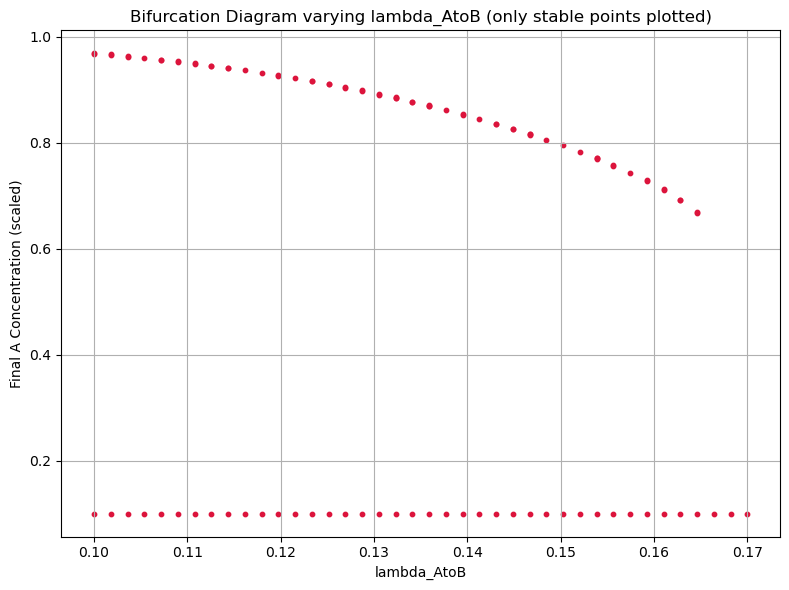

In [17]:
# Plotting the bifurcation diagram
plt.figure(figsize=(8, 6))
for lambda_AtoB, final_A_set in results:
    plt.scatter([lambda_AtoB] * len(final_A_set), final_A_set, color="crimson", s=10)
plt.xlabel("lambda_AtoB")
plt.ylabel("Final A Concentration (scaled)")
plt.title("Bifurcation Diagram varying lambda_AtoB (only stable points plotted)")
plt.grid(True)
plt.tight_layout()
plt.show()